In [22]:
# ── Cell 1: imports ───────────────────────────────────────────────────────────
%matplotlib inline
 
import io
import os
import warnings
import requests
import numpy as np
import geopandas as gpd
import rasterio
import rasterio.features
import rasterio.mask
import rasterio.transform
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
from rasterio.transform import Affine
from rasterio.windows import from_bounds
from shapely.geometry import shape
 
warnings.filterwarnings("ignore")

In [32]:
# ── Cell 2: download Hansen Global Forest Change rasters ──────────────────────
# Tile 10S_060W covers Rondônia, Brazil
# lossyear: which year each pixel lost tree cover (0=no loss, 1–23=2001–2023)
# treecover2000: % tree cover in year 2000 (baseline)
 
def download_file(url, out_path):
    if os.path.exists(out_path):
        print(f"Already exists: {out_path}")
        return out_path
    print(f"Downloading {out_path}...")
    r = requests.get(url, verify=False, stream=True, timeout=120)
    r.raise_for_status()
    total      = int(r.headers.get("content-length", 0))
    downloaded = 0
    with open(out_path, "wb") as f:
        for chunk in r.iter_content(chunk_size=1024 * 512):
            f.write(chunk)
            downloaded += len(chunk)
            if total:
                print(f"  {downloaded/1e6:.1f} / {total/1e6:.1f} MB", end="\r")
    print(f"\n  Done: {out_path}")
    return out_path
 
lossyear_url = (
    "https://storage.googleapis.com/earthenginepartners-hansen/"
    "GFC-2023-v1.11/Hansen_GFC-2023-v1.11_lossyear_10S_060W.tif"
)
treecover_url = (
    "https://storage.googleapis.com/earthenginepartners-hansen/"
    "GFC-2023-v1.11/Hansen_GFC-2023-v1.11_treecover2000_10S_060W.tif"
)
 
lossyear_path  = download_file(lossyear_url,  "lossyear_rondoniai.tif")
treecover_path = download_file(treecover_url, "treecover2000_rondoniai.tif")

Already exists: lossyear_rondoniai.tif
Already exists: treecover2000_rondoniai.tif


In [33]:
# ── Cell 3: inspect the rasters ──────────────────────────────────────────────
with rasterio.open(lossyear_path) as src:
    print("Loss year raster:")
    print(f"  Shape:      {src.shape}")
    print(f"  CRS:        {src.crs}")
    print(f"  Resolution: {src.res}")
    print(f"  Bounds:     {src.bounds}")
    lossyear           = src.read(1)
    lossyear_transform = src.transform
    lossyear_crs       = src.crs
 
with rasterio.open(treecover_path) as src:
    print("\nTree cover raster:")
    print(f"  Shape: {src.shape}")
    print(f"  CRS:   {src.crs}")
    treecover = src.read(1)
 
print(f"\nLoss year unique values (sample): {np.unique(lossyear)[:15]}")
print(f"Tree cover range: {treecover.min()} – {treecover.max()}%")
print(f"Pixels with any loss: {np.sum(lossyear > 0):,}")

Loss year raster:
  Shape:      (40000, 40000)
  CRS:        EPSG:4326
  Resolution: (0.00025, 0.00025)
  Bounds:     BoundingBox(left=-60.0, bottom=-20.0, right=-50.0, top=-10.0)

Tree cover raster:
  Shape: (40000, 40000)
  CRS:   EPSG:4326

Loss year unique values (sample): [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14]
Tree cover range: 0 – 100%
Pixels with any loss: 204,954,710


In [34]:
# ── Cell 4: clip to Rondônia and downsample ───────────────────────────────────
RON_BOUNDS = (-60.0, -13.5, -57.0, -7.5)
 
def read_clipped(path, bounds):
    with rasterio.open(path) as src:
        window    = from_bounds(bounds[0], bounds[1], bounds[2], bounds[3], src.transform)
        data      = src.read(1, window=window)
        transform = src.window_transform(window)
        crs       = src.crs
    return data, transform, crs
 
lossyear,  lossyear_transform,  lossyear_crs = read_clipped(lossyear_path,  RON_BOUNDS)
treecover, treecover_transform, _            = read_clipped(treecover_path, RON_BOUNDS)
 
print(f"Clipped shape: {lossyear.shape}")
 
step         = 10
lossyear_ds  = lossyear[::step, ::step]
treecover_ds = treecover[::step, ::step]
ds_transform = Affine(
    lossyear_transform.a * step, lossyear_transform.b, lossyear_transform.c,
    lossyear_transform.d, lossyear_transform.e * step, lossyear_transform.f,
)
 
print(f"Downsampled shape: {lossyear_ds.shape}")
print(f"Pixels with loss in Rondônia: {np.sum(lossyear > 0):,}")

Clipped shape: (14000, 12000)
Downsampled shape: (1400, 1200)
Pixels with loss in Rondônia: 29,158,644


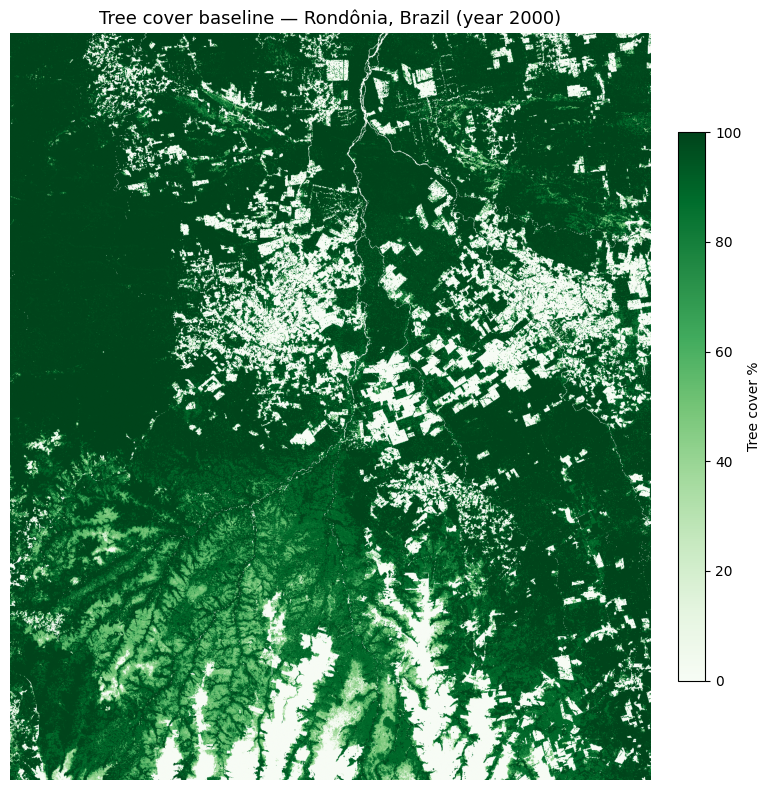

In [27]:
# ── Cell 5: plot tree cover baseline (year 2000) ──────────────────────────────
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(treecover_ds, cmap="Greens", vmin=0, vmax=100)
plt.colorbar(im, ax=ax, fraction=0.03, pad=0.03, label="Tree cover %")
ax.set_title("Tree cover baseline — Rondônia, Brazil (year 2000)", fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.show()
plt.close()

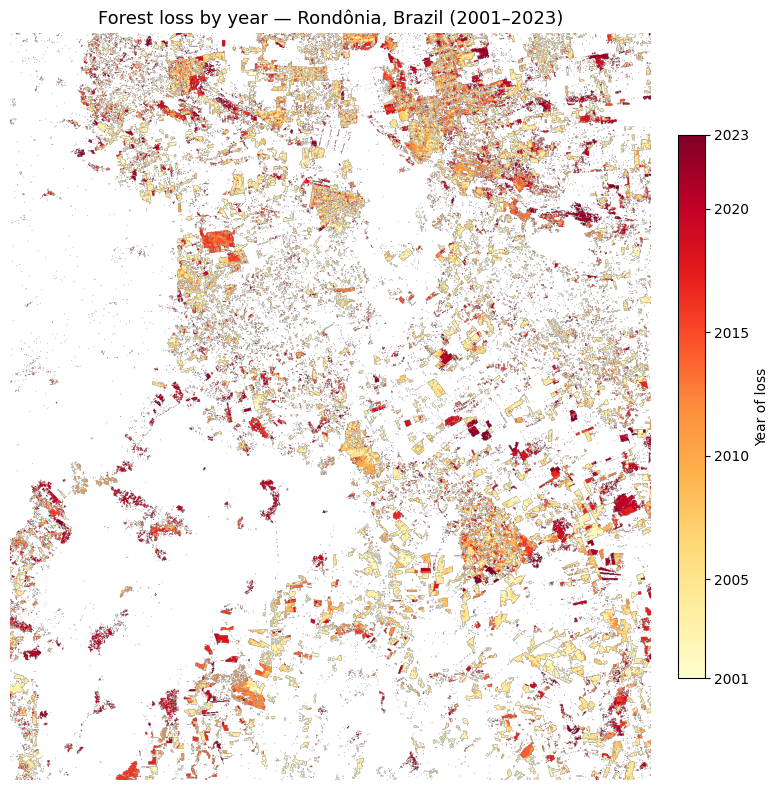

In [28]:
# ── Cell 6: plot deforestation by year ───────────────────────────────────────
loss_masked = np.where(lossyear_ds > 0, lossyear_ds, np.nan)
 
fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(loss_masked, cmap="YlOrRd", vmin=1, vmax=23)
cbar = plt.colorbar(im, ax=ax, fraction=0.03, pad=0.03)
cbar.set_label("Year of loss")
cbar.set_ticks([1, 5, 10, 15, 20, 23])
cbar.set_ticklabels(["2001", "2005", "2010", "2015", "2020", "2023"])
ax.set_title("Forest loss by year — Rondônia, Brazil (2001–2023)", fontsize=13)
ax.set_axis_off()
plt.tight_layout()
plt.show()
plt.close()

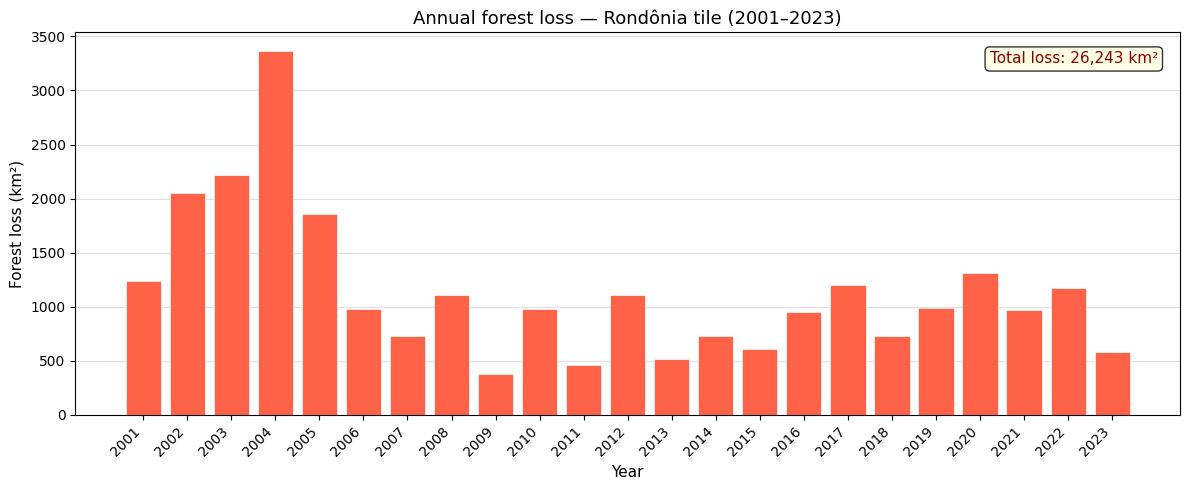

In [29]:
# ── Cell 7: loss area by year (bar chart) ────────────────────────────────────
pixel_area_km2 = 0.0009
 
years       = list(range(1, 24))
loss_km2    = [np.sum(lossyear == y) * pixel_area_km2 for y in years]
year_labels = [str(2000 + y) for y in years]
 
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(year_labels, loss_km2, color="tomato", edgecolor="white", linewidth=0.5)
ax.set_xlabel("Year", fontsize=11)
ax.set_ylabel("Forest loss (km²)", fontsize=11)
ax.set_title("Annual forest loss — Rondônia tile (2001–2023)", fontsize=13)
plt.xticks(rotation=45, ha="right")
ax.yaxis.grid(True, alpha=0.4)
ax.set_axisbelow(True)
total_km2 = sum(loss_km2)
ax.text(
    0.98, 0.95, f"Total loss: {total_km2:,.0f} km²",
    transform=ax.transAxes, ha="right", va="top", fontsize=11, color="darkred",
    bbox=dict(boxstyle="round,pad=0.3", facecolor="lightyellow", alpha=0.8),
)
plt.tight_layout()
plt.show()
plt.close()

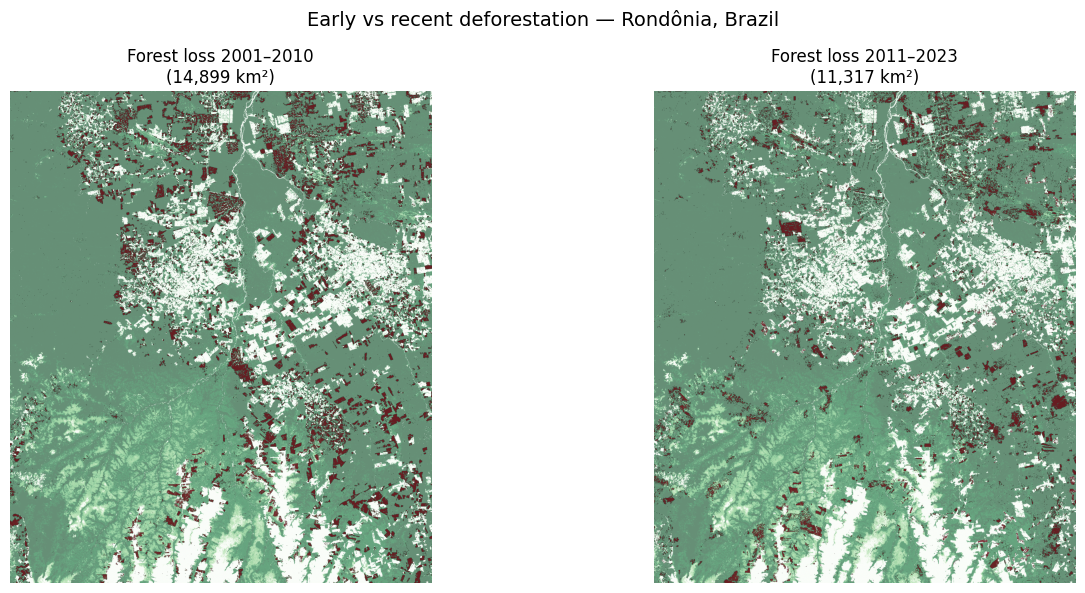

In [30]:
# ── Cell 8: compare early (2001–2010) vs recent (2011–2023) loss ─────────────
early  = np.isin(lossyear_ds, range(1, 11)).astype(np.uint8)
recent = np.isin(lossyear_ds, range(11, 24)).astype(np.uint8)
 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, mask, label in zip(
    axes,
    [early, recent],
    [f"Forest loss 2001–2010\n({np.sum(early>0)*pixel_area_km2*100:,.0f} km²)",
     f"Forest loss 2011–2023\n({np.sum(recent>0)*pixel_area_km2*100:,.0f} km²)"],
):
    ax.imshow(treecover_ds, cmap="Greens", vmin=0, vmax=100, alpha=0.6)
    ax.imshow(np.where(mask, 1, np.nan), cmap="Reds", vmin=0, vmax=1, alpha=0.8)
    ax.set_title(label, fontsize=12)
    ax.set_axis_off()
 
fig.suptitle("Early vs recent deforestation — Rondônia, Brazil", fontsize=14)
plt.tight_layout()
plt.show()
plt.close()

In [31]:
# ── Cell 9: vectorise 2019–2023 loss and compute area ────────────────────────
recent_loss = np.isin(lossyear, range(19, 24)).astype(np.uint8)
 
loss_shapes = [
    shape(geom)
    for geom, val in rasterio.features.shapes(recent_loss, transform=lossyear_transform)
    if val == 1
]
 
loss_gdf                    = gpd.GeoDataFrame(geometry=loss_shapes, crs=lossyear_crs)
loss_gdf_metric             = loss_gdf.to_crs("EPSG:32720")
loss_gdf_metric["area_km2"] = loss_gdf_metric.geometry.area / 1e6
total_recent_km2            = loss_gdf_metric["area_km2"].sum()
 
print(f"Loss polygons (2019–2023): {len(loss_gdf):,}")
print(f"Total recent loss area:    {total_recent_km2:,.1f} km²")

Loss polygons (2019–2023): 241,921
Total recent loss area:    4,269.1 km²
